# Exploratory Data Analysis — Cleaned Hourly Dataset

**Input:** `data/processed/ev_cleaned_hourly.parquet` — 586 stations, 10.3M rows, 39 columns

---

## Column Reference

| # | Column | Type | Description |
|---|--------|------|-------------|
| | **Identifiers** | | |
| 1 | `customer_id` | int64 | Unique station identifier |
| 2 | `timestamp_hour` | datetime | Hour-level timestamp (2021-01-01 to 2022-12-31) |
| | **Load values** | | |
| 3 | `load_kwh_clean` | float32 | Primary load value — cleaned, with short-gap forward-fill applied |
| 4 | `load_kwh_hourly` | float32 | Raw hourly load — sum of observed 15-min values, NaN if all 4 quarters missing |
| 5 | `load_kwh_hourly_scaled` | float64 | Partial-hour scaled load — extrapolates partial hours to full hour (e.g. 2 quarters observed × 2) |
| | **Observation quality** | | |
| 6 | `observed_quarters` | Int8 | Count of non-null 15-min slots in this hour (0–4) |
| 7 | `missing_quarters` | Int8 | 4 − observed_quarters |
| 8 | `partial_hour` | bool | True if 1–3 quarters observed (not fully missing, not fully observed) |
| 9 | `partial_hour_scaled` | bool | Same as partial_hour — flags rows where scaling was applied |
| | **Data quality flags** | | |
| 10 | `imputed_ffill` | bool | True if this row was filled by forward-fill (was NaN, gap ≤ 3 hours) |
| 11 | `load_flag_negative_corrected` | bool | True if original value was negative and corrected to 0 |
| 12 | `load_flag_outlier` | bool | True if flagged as outlier by either method (z-score OR IQR) |
| 13 | `load_flag_outlier_zscore` | bool | True if \|value − station_mean\| > 4σ |
| 14 | `load_flag_outlier_iqr` | bool | True if value > Q75 + 1.5 × IQR (per station) |
| | **Demand response** | | |
| 15 | `is_dr_event` | bool | True if any quarter in this hour was a demand response event |
| 16 | `dr_performance_kwh_hourly` | float32 | DR performance in kWh for this hour (NaN if not a DR event) |
| 17 | `exclude_from_baseline` | bool | Convenience flag — same as is_dr_event, marks hours to exclude from baseline modeling |
| | **Station metadata** | | |
| 18 | `public_private` | string | Public Charger or Private Charger |
| 19 | `business_type` | string | Publicly Owned Charger, Privately Owned Charger, or Rent-A-Car |
| 20 | `contract_type` | string | Commercial Power (Type A) I or Residential Power (High Voltage) |
| 21 | `detailed_type` | string | Low Voltage or High Voltage A |
| 22 | `contract_power_kw` | float32 | Maximum contracted power capacity (kW) |
| 23 | `total_quantity` | Int16 | Total number of chargers at the station |
| 24 | `charger_7kw` | Int16 | Count of 7 kW chargers |
| 25 | `charger_8kw` | Int16 | Count of 8 kW chargers |
| 26 | `other_slow_charger` | Int16 | Count of other slow chargers |
| 27 | `charger_50kw` | Int16 | Count of 50 kW fast chargers |
| 28 | `other_fast_charger` | Int16 | Count of other fast chargers |
| 29 | `participate_program` | string | DR program participation label |
| 30 | `province` | string | Province — all stations are on Jeju Island |
| 31 | `city` | string | City — Jeju-Si or Seogwipo-Si |
| 32 | `address` | string | Full street address |
| | **Time features** | | |
| 33 | `hour` | int32 | Hour of day (0–23) |
| 34 | `day_of_week` | int32 | Day of week (0=Monday, 6=Sunday) |
| 35 | `is_weekend` | bool | True if Saturday or Sunday |
| 36 | `month` | int32 | Month (1–12) |
| 37 | `season` | string | winter, spring, summer, fall |
| 38 | `year` | int32 | 2021 or 2022 |
| 39 | `is_holiday` | bool | True if South Korean public holiday |

## 0. Setup & Load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Find the project root
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'ev_cleaned_hourly.parquet'

df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Stations: {df["customer_id"].nunique()}')
print(f'Date range: {df["timestamp_hour"].min()} → {df["timestamp_hour"].max()}')

Shape: 10,266,720 rows × 39 cols
Memory: 7874.5 MB
Stations: 586
Date range: 2021-01-01 00:00:00 → 2022-12-31 23:00:00


In [2]:
# Baseline subset: non-NaN, non-DR, non-imputed, non-outlier hours
# This is the "trustworthy" slice for understanding normal charging patterns.
baseline = df[
    df['load_kwh_clean'].notna() &
    ~df['exclude_from_baseline'] &
    ~df['imputed_ffill'] &
    ~df['load_flag_outlier']
].copy()

print(f'Baseline rows: {len(baseline):,}  ({len(baseline)/len(df)*100:.1f}% of full dataset)')
print(f'Stations in baseline: {baseline["customer_id"].nunique()}')

Baseline rows: 6,429,940  (62.6% of full dataset)
Stations in baseline: 586


## 1. Temporal Patterns

How does charging demand change across hours, days, and seasons?

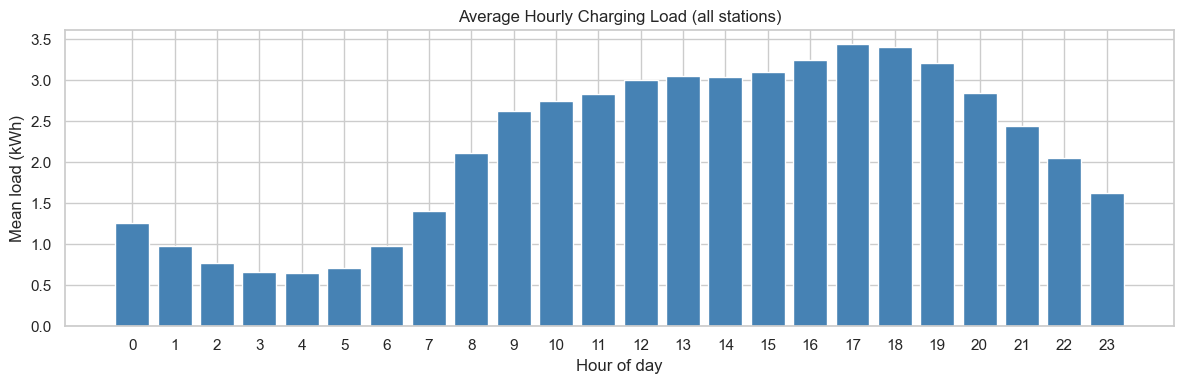

Peak hour:   17:00  (3.44 kWh avg)
Trough hour: 4:00  (0.65 kWh avg)


In [3]:
# --- Hourly profile (mean load by hour of day) ---
hourly_avg = baseline.groupby('hour')['load_kwh_clean'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly_avg.index, hourly_avg.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean load (kWh)')
ax.set_title('Average Hourly Charging Load (all stations)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

peak_hour = hourly_avg.idxmax()
trough_hour = hourly_avg.idxmin()
print(f'Peak hour:   {peak_hour}:00  ({hourly_avg[peak_hour]:.2f} kWh avg)')
print(f'Trough hour: {trough_hour}:00  ({hourly_avg[trough_hour]:.2f} kWh avg)')

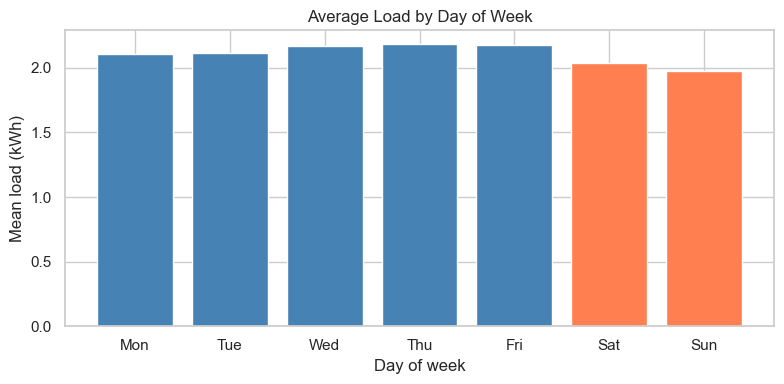

Weekday avg: 2.150 kWh
Weekend avg: 2.005 kWh
Ratio (weekend/weekday): 0.93


In [4]:
# --- Day-of-week profile ---
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg = baseline.groupby('day_of_week')['load_kwh_clean'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['coral' if d >= 5 else 'steelblue' for d in dow_avg.index]
ax.bar(dow_avg.index, dow_avg.values, color=colors, edgecolor='white')
ax.set_xlabel('Day of week')
ax.set_ylabel('Mean load (kWh)')
ax.set_title('Average Load by Day of Week')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
plt.tight_layout()
plt.show()

weekday_avg = baseline[~baseline['is_weekend']]['load_kwh_clean'].mean()
weekend_avg = baseline[baseline['is_weekend']]['load_kwh_clean'].mean()
print(f'Weekday avg: {weekday_avg:.3f} kWh')
print(f'Weekend avg: {weekend_avg:.3f} kWh')
print(f'Ratio (weekend/weekday): {weekend_avg/weekday_avg:.2f}')

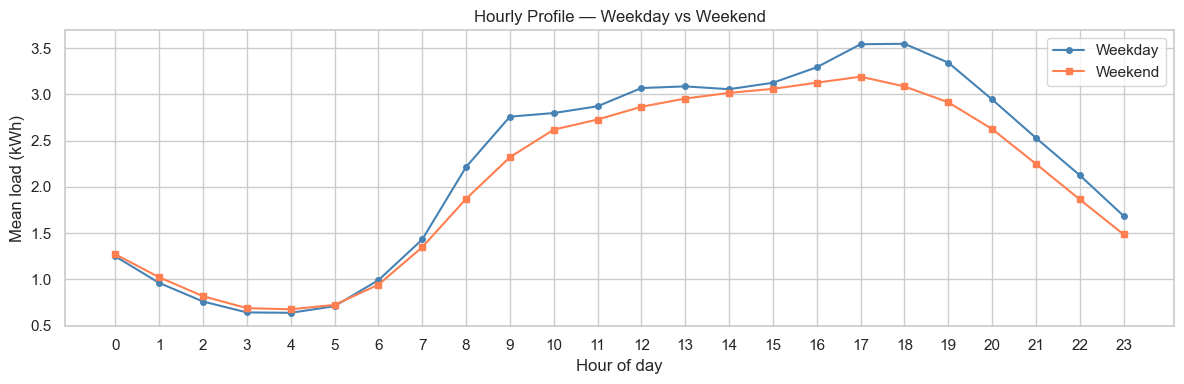

In [5]:
# --- Hourly profile: weekday vs weekend ---
hourly_wd = baseline[~baseline['is_weekend']].groupby('hour')['load_kwh_clean'].mean()
hourly_we = baseline[baseline['is_weekend']].groupby('hour')['load_kwh_clean'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_wd.index, hourly_wd.values, marker='o', markersize=4, label='Weekday', color='steelblue')
ax.plot(hourly_we.index, hourly_we.values, marker='s', markersize=4, label='Weekend', color='coral')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean load (kWh)')
ax.set_title('Hourly Profile — Weekday vs Weekend')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

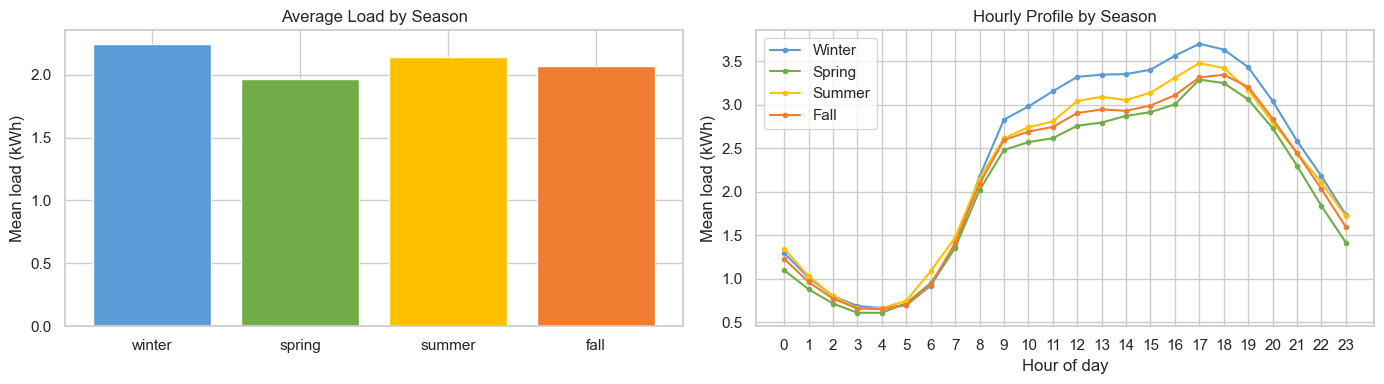

In [6]:
# --- Seasonal patterns ---
season_order = ['winter', 'spring', 'summer', 'fall']
season_avg = baseline.groupby('season')['load_kwh_clean'].mean().reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of seasonal averages
axes[0].bar(season_avg.index, season_avg.values, color=['#5B9BD5', '#70AD47', '#FFC000', '#ED7D31'], edgecolor='white')
axes[0].set_ylabel('Mean load (kWh)')
axes[0].set_title('Average Load by Season')

# Hourly profile by season
season_colors = {'winter': '#5B9BD5', 'spring': '#70AD47', 'summer': '#FFC000', 'fall': '#ED7D31'}
for season in season_order:
    s = baseline[baseline['season'] == season].groupby('hour')['load_kwh_clean'].mean()
    axes[1].plot(s.index, s.values, marker='o', markersize=3, label=season.title(), color=season_colors[season])
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean load (kWh)')
axes[1].set_title('Hourly Profile by Season')
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.tight_layout()
plt.show()

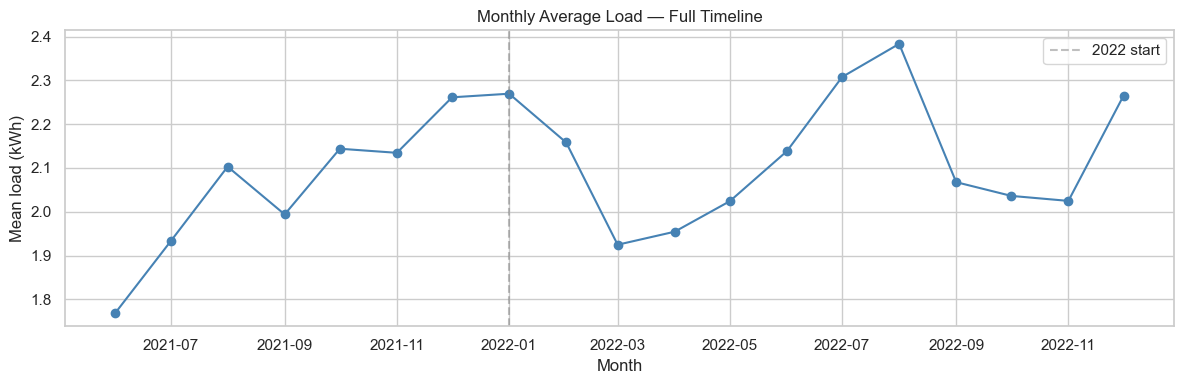

2021 avg: 2.066 kWh
2022 avg: 2.128 kWh
YoY change: +3.0%


In [7]:
# --- Monthly trend (2021 vs 2022) ---
monthly = baseline.groupby(['year', 'month'])['load_kwh_clean'].mean().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['date'], monthly['load_kwh_clean'], marker='o', color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Mean load (kWh)')
ax.set_title('Monthly Average Load — Full Timeline')
ax.axvline(pd.Timestamp('2022-01-01'), color='gray', linestyle='--', alpha=0.5, label='2022 start')
ax.legend()
plt.tight_layout()
plt.show()

y2021 = baseline[baseline['year'] == 2021]['load_kwh_clean'].mean()
y2022 = baseline[baseline['year'] == 2022]['load_kwh_clean'].mean()
print(f'2021 avg: {y2021:.3f} kWh')
print(f'2022 avg: {y2022:.3f} kWh')
print(f'YoY change: {(y2022 - y2021) / y2021 * 100:+.1f}%')

In [8]:
# --- Holiday vs non-holiday ---
hol_avg = baseline[baseline['is_holiday']]['load_kwh_clean'].mean()
nohol_avg = baseline[~baseline['is_holiday']]['load_kwh_clean'].mean()

print(f'Holiday avg:     {hol_avg:.3f} kWh')
print(f'Non-holiday avg: {nohol_avg:.3f} kWh')
print(f'Ratio (holiday/non-holiday): {hol_avg/nohol_avg:.2f}')

Holiday avg:     2.015 kWh
Non-holiday avg: 2.112 kWh
Ratio (holiday/non-holiday): 0.95


## 2. Station-Level Variation

How different are stations from each other? Are there natural groups?

In [9]:
# --- Per-station summary stats ---
station_stats = (
    baseline.groupby('customer_id')['load_kwh_clean']
    .agg(['mean', 'median', 'std', 'max', 'count'])
    .rename(columns={'count': 'obs_hours'})
    .reset_index()
)

# Merge metadata for grouping
meta_cols = ['customer_id', 'business_type', 'public_private', 'city',
             'contract_power_kw', 'total_quantity', 'charger_50kw']
station_meta = df[meta_cols].drop_duplicates('customer_id')
station_stats = station_stats.merge(station_meta, on='customer_id')

print(f'Station count: {len(station_stats)}')
print(f'\nMean load per station:')
print(station_stats['mean'].describe())

Station count: 586

Mean load per station:
count   586.0000
mean      1.9109
std       6.5916
min       0.0000
25%       0.0393
50%       0.1526
75%       1.6105
max     128.2694
Name: mean, dtype: float64


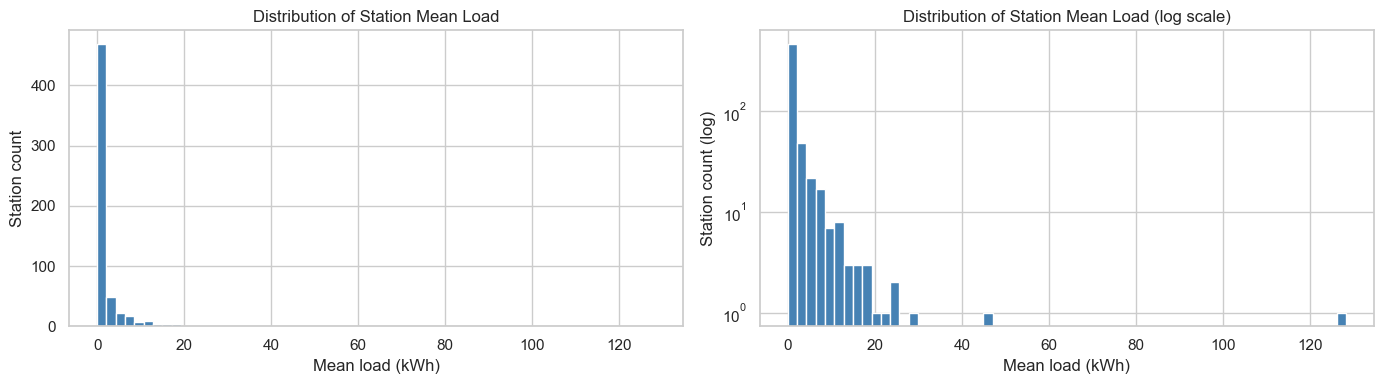

Stations with mean load < 1 kWh: 410 (70.0%)


In [10]:
# --- Distribution of station mean load ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(station_stats['mean'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Mean load (kWh)')
axes[0].set_ylabel('Station count')
axes[0].set_title('Distribution of Station Mean Load')

axes[1].hist(station_stats['mean'], bins=60, color='steelblue', edgecolor='white', log=True)
axes[1].set_xlabel('Mean load (kWh)')
axes[1].set_ylabel('Station count (log)')
axes[1].set_title('Distribution of Station Mean Load (log scale)')

plt.tight_layout()
plt.show()

# How many stations are mostly idle?
low_use = (station_stats['mean'] < 1).sum()
print(f'Stations with mean load < 1 kWh: {low_use} ({low_use/len(station_stats)*100:.1f}%)')

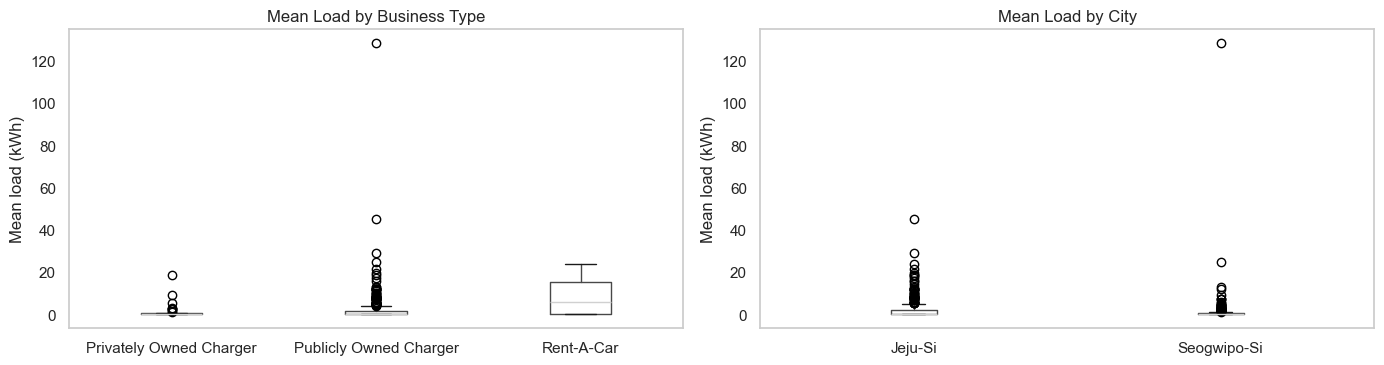

Mean load by business_type:
                           count   mean    std    min    25%    50%     75%  \
business_type                                                                 
Privately Owned Charger  41.0000 1.1820 3.3070 0.0060 0.0100 0.0230  0.3580   
Publicly Owned Charger  534.0000 1.8360 6.6740 0.0000 0.0400 0.1630  1.6020   
Rent-A-Car               11.0000 8.2390 8.8110 0.0000 0.0610 5.7310 15.0480   

                             max  
business_type                     
Privately Owned Charger  18.7190  
Publicly Owned Charger  128.2690  
Rent-A-Car               23.8550  

Mean load by city:
               count   mean    std    min    25%    50%    75%      max
city                                                                   
Jeju-Si     382.0000 2.0570 4.5760 0.0000 0.0390 0.1630 1.9340  44.9850
Seogwipo-Si 204.0000 1.6380 9.2630 0.0000 0.0400 0.1450 0.5100 128.2690


In [11]:
# --- Mean load by business type ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

station_stats.boxplot(column='mean', by='business_type', ax=axes[0], grid=False)
axes[0].set_title('Mean Load by Business Type')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean load (kWh)')
plt.suptitle('')

station_stats.boxplot(column='mean', by='city', ax=axes[1], grid=False)
axes[1].set_title('Mean Load by City')
axes[1].set_xlabel('')
axes[1].set_ylabel('Mean load (kWh)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Mean load by business_type:')
print(station_stats.groupby('business_type')['mean'].describe().round(3))
print('\nMean load by city:')
print(station_stats.groupby('city')['mean'].describe().round(3))

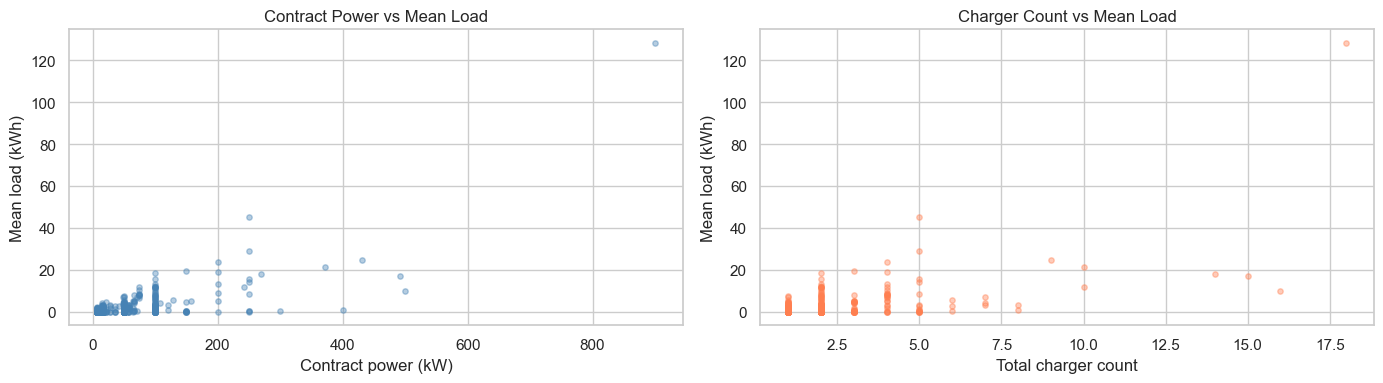

Correlation (contract_power_kw vs mean load): 0.698
Correlation (total_quantity vs mean load):     0.603


In [12]:
# --- Relationship between station capacity and usage ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(station_stats['contract_power_kw'], station_stats['mean'],
                alpha=0.4, s=15, color='steelblue')
axes[0].set_xlabel('Contract power (kW)')
axes[0].set_ylabel('Mean load (kWh)')
axes[0].set_title('Contract Power vs Mean Load')

axes[1].scatter(station_stats['total_quantity'], station_stats['mean'],
                alpha=0.4, s=15, color='coral')
axes[1].set_xlabel('Total charger count')
axes[1].set_ylabel('Mean load (kWh)')
axes[1].set_title('Charger Count vs Mean Load')

plt.tight_layout()
plt.show()

corr_power = station_stats[['mean', 'contract_power_kw']].corr().iloc[0, 1]
corr_qty = station_stats[['mean', 'total_quantity']].corr().iloc[0, 1]
print(f'Correlation (contract_power_kw vs mean load): {corr_power:.3f}')
print(f'Correlation (total_quantity vs mean load):     {corr_qty:.3f}')

In [13]:
# --- Top 10 and bottom 10 stations by usage ---
top10 = station_stats.nlargest(10, 'mean')[['customer_id', 'mean', 'median', 'max', 'obs_hours', 'business_type', 'city', 'contract_power_kw']]
bot10 = station_stats.nsmallest(10, 'mean')[['customer_id', 'mean', 'median', 'max', 'obs_hours', 'business_type', 'city', 'contract_power_kw']]

print('Top 10 stations by mean load:')
print(top10.to_string(index=False))
print('\nBottom 10 stations by mean load:')
print(bot10.to_string(index=False))

Top 10 stations by mean load:
 customer_id     mean   median      max  obs_hours           business_type        city  contract_power_kw
   811236417 128.2694 120.2050 235.9100      11818  Publicly Owned Charger Seogwipo-Si           900.0000
   812191515  44.9855  41.7300 149.0300      13821  Publicly Owned Charger     Jeju-Si           250.0000
   812174605  28.7711  23.6350 107.6600      13714  Publicly Owned Charger     Jeju-Si           250.0000
   813647087  24.6891  10.5200 111.5800      11809  Publicly Owned Charger Seogwipo-Si           431.0000
   812962399  23.8551   4.2560 116.8200      13827              Rent-A-Car     Jeju-Si           200.0000
   813258684  21.4051  16.8800  72.8400      12049  Publicly Owned Charger     Jeju-Si           371.0000
   812992507  19.6017   0.0780  95.2380       6287  Publicly Owned Charger     Jeju-Si           150.0000
   812920443  18.7191   0.1920  96.2080       7291 Privately Owned Charger     Jeju-Si           200.0000
   812723040  18

## 3. Station 
MapJeju Island nSpatial distribution of the 586 cleaned stations. Requires `data/interim/station_coordinates.csv` from notebook `02 - Geocode Stations`.

Stations with coordinates: 586 / 586

Stations by island:
island
Jeju (main)     580
Udo Island        5
Chuja Island      1
Name: count, dtype: int64


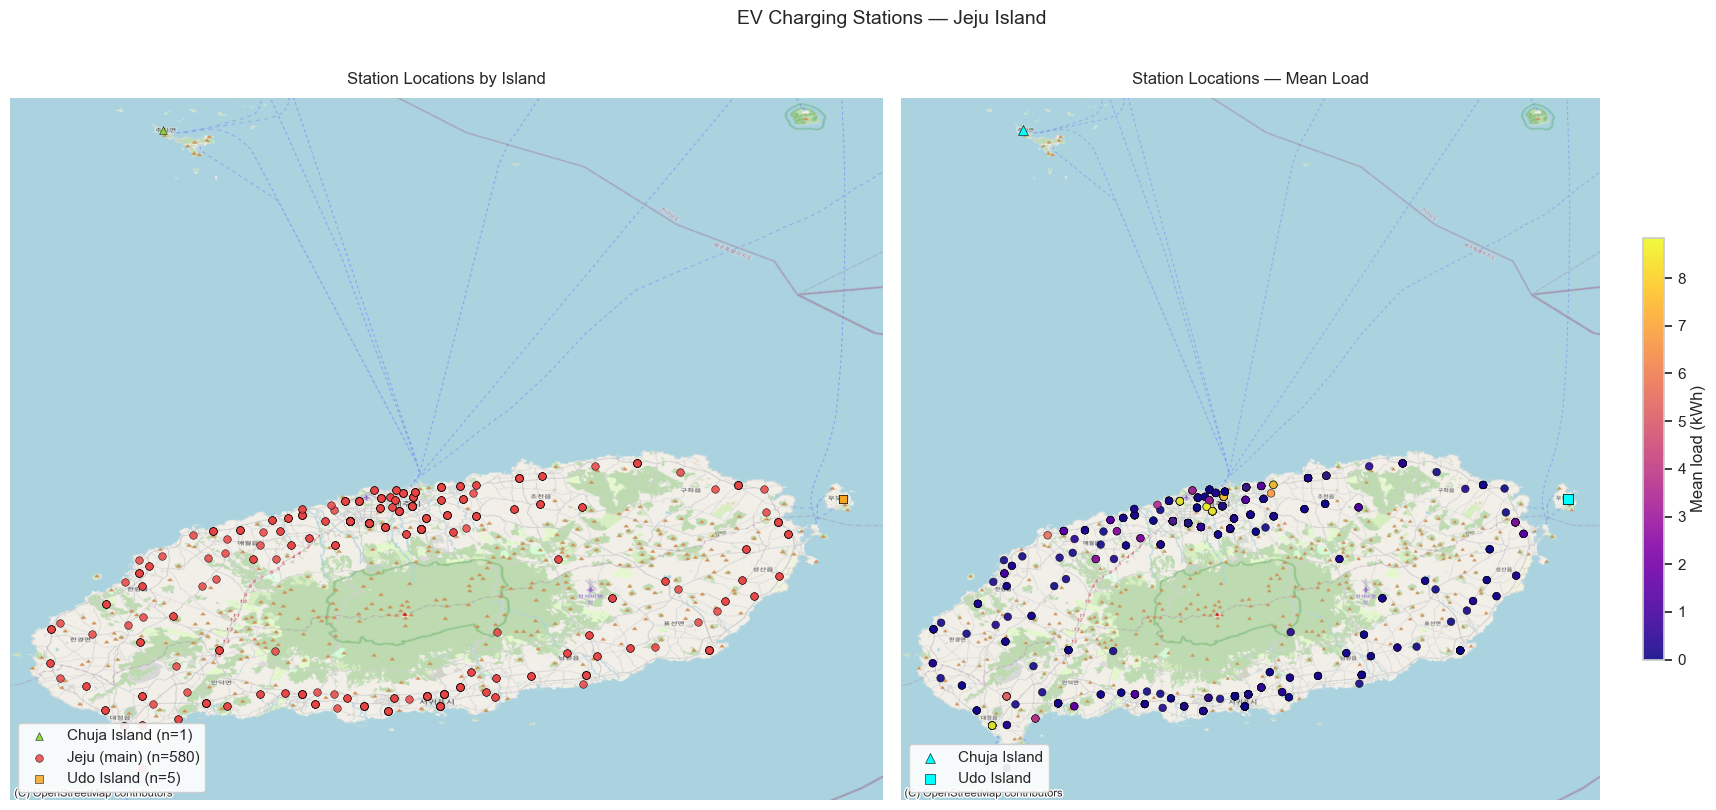

In [17]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

COORDS_PATH = PROJECT_ROOT / 'data' / 'interim' / 'station_coordinates.csv'

if not COORDS_PATH.exists():
    print('station_coordinates.csv not found — run 02 - Geocode Stations first.')
else:
    coords = pd.read_csv(COORDS_PATH).dropna(subset=['lat', 'lon'])

    # Filter to cleaned stations only
    cleaned_ids = set(df['customer_id'].unique())
    coords = coords[coords['customer_id'].isin(cleaned_ids)].copy()
    print(f'Stations with coordinates: {len(coords)} / {len(cleaned_ids)}')

    # Classify by island
    def classify_island(row):
        if row['lat'] > 33.7:
            return 'Chuja Island'
        elif row['lon'] > 126.95:
            return 'Udo Island'
        else:
            return 'Jeju (main)'

    coords['island'] = coords.apply(classify_island, axis=1)
    print('\nStations by island:')
    print(coords['island'].value_counts())

    # Merge station mean load
    coords = coords.merge(
        station_stats[['customer_id', 'mean', 'business_type', 'city']],
        on='customer_id', how='left'
    )

    # Build GeoDataFrame (WGS84) then reproject to Web Mercator for contextily
    gdf = gpd.GeoDataFrame(
        coords,
        geometry=[Point(lon, lat) for lon, lat in zip(coords['lon'], coords['lat'])],
        crs='EPSG:4326'
    ).to_crs(epsg=3857)

    island_colors  = {'Jeju (main)': '#e84545', 'Udo Island': '#f5a623', 'Chuja Island': '#7ed321'}
    island_markers = {'Jeju (main)': 'o', 'Udo Island': 's', 'Chuja Island': '^'}

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # --- Left: stations by island ---
    for island, group in gdf.groupby('island'):
        axes[0].scatter(
            group.geometry.x, group.geometry.y,
            s=30, alpha=0.85,
            color=island_colors[island],
            marker=island_markers[island],
            label=f'{island} (n={len(group)})',
            zorder=3, edgecolors='black', linewidths=0.4
        )
    ctx.add_basemap(axes[0], source=ctx.providers.OpenStreetMap.Mapnik, zoom=11)
    axes[0].set_axis_off()
    axes[0].set_title('Station Locations by Island', fontsize=12, pad=10)
    axes[0].legend(loc='lower left', framealpha=0.9)

    # --- Right: color by mean load ---
    main_gdf = gdf[gdf['island'] == 'Jeju (main)']
    vmax = main_gdf['mean'].quantile(0.95)
    sc = axes[1].scatter(
        main_gdf.geometry.x, main_gdf.geometry.y,
        c=main_gdf['mean'], cmap='plasma',
        s=30, alpha=0.9, vmin=0, vmax=vmax,
        zorder=3, edgecolors='black', linewidths=0.4
    )
    # Overlay outlying islands in gray
    for island, group in gdf[gdf['island'] != 'Jeju (main)'].groupby('island'):
        axes[1].scatter(
            group.geometry.x, group.geometry.y,
            s=50, color='cyan',
            marker=island_markers[island],
            label=island, zorder=4,
            edgecolors='black', linewidths=0.4
        )
    ctx.add_basemap(axes[1], source=ctx.providers.OpenStreetMap.Mapnik, zoom=11)
    plt.colorbar(sc, ax=axes[1], label='Mean load (kWh)', shrink=0.6)
    axes[1].set_axis_off()
    axes[1].set_title('Station Locations — Mean Load', fontsize=12, pad=10)
    axes[1].legend(loc='lower left', framealpha=0.9)

    plt.suptitle('EV Charging Stations — Jeju Island', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## 3. Load Distribution

What does the load distribution look like? How common is zero usage?

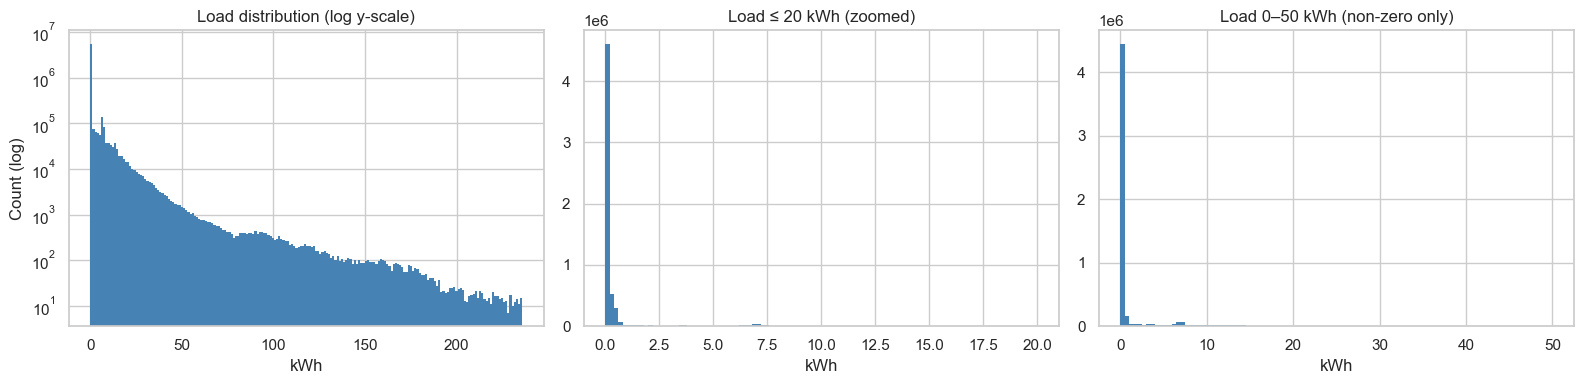

Zero-load hours: 908,554 (14.1%)

Percentiles:
  P10: 0.00 kWh
  P25: 0.02 kWh
  P50: 0.08 kWh
  P75: 0.29 kWh
  P90: 6.11 kWh
  P95: 12.12 kWh
  P99: 35.72 kWh


In [ ]:
# --- Overall load distribution ---
load_vals = baseline['load_kwh_clean']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(load_vals, bins=200, color='steelblue', edgecolor='none', log=True)
axes[0].set_title('Load distribution (log y-scale)')
axes[0].set_xlabel('kWh')
axes[0].set_ylabel('Count (log)')

axes[1].hist(load_vals[load_vals <= 20], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Load ≤ 20 kWh (zoomed)')
axes[1].set_xlabel('kWh')

axes[2].hist(load_vals[(load_vals > 0) & (load_vals <= 50)], bins=100, color='steelblue', edgecolor='none')
axes[2].set_title('Load 0–50 kWh (non-zero only)')
axes[2].set_xlabel('kWh')

plt.tight_layout()
plt.show()

zero_pct = (load_vals == 0).mean() * 100
print(f'Zero-load hours: {(load_vals == 0).sum():,} ({zero_pct:.1f}%)')
print(f'\nPercentiles:')
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f'  P{p}: {load_vals.quantile(p/100):.2f} kWh')

## 4. Heatmaps

Hour × day-of-week patterns to visualize when charging happens.

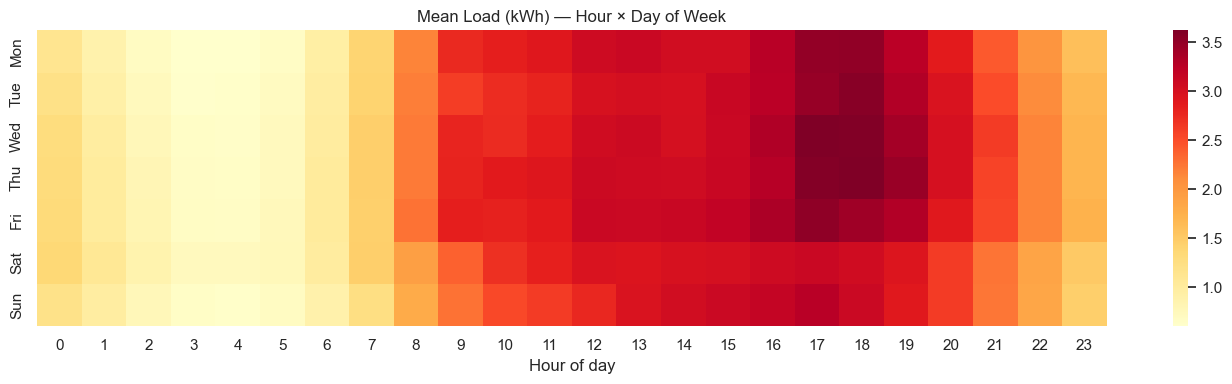

In [ ]:
# --- Hour × day-of-week heatmap ---
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = baseline.groupby(['day_of_week', 'hour'])['load_kwh_clean'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, xticklabels=True, yticklabels=dow_labels)
ax.set_title('Mean Load (kWh) — Hour × Day of Week')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

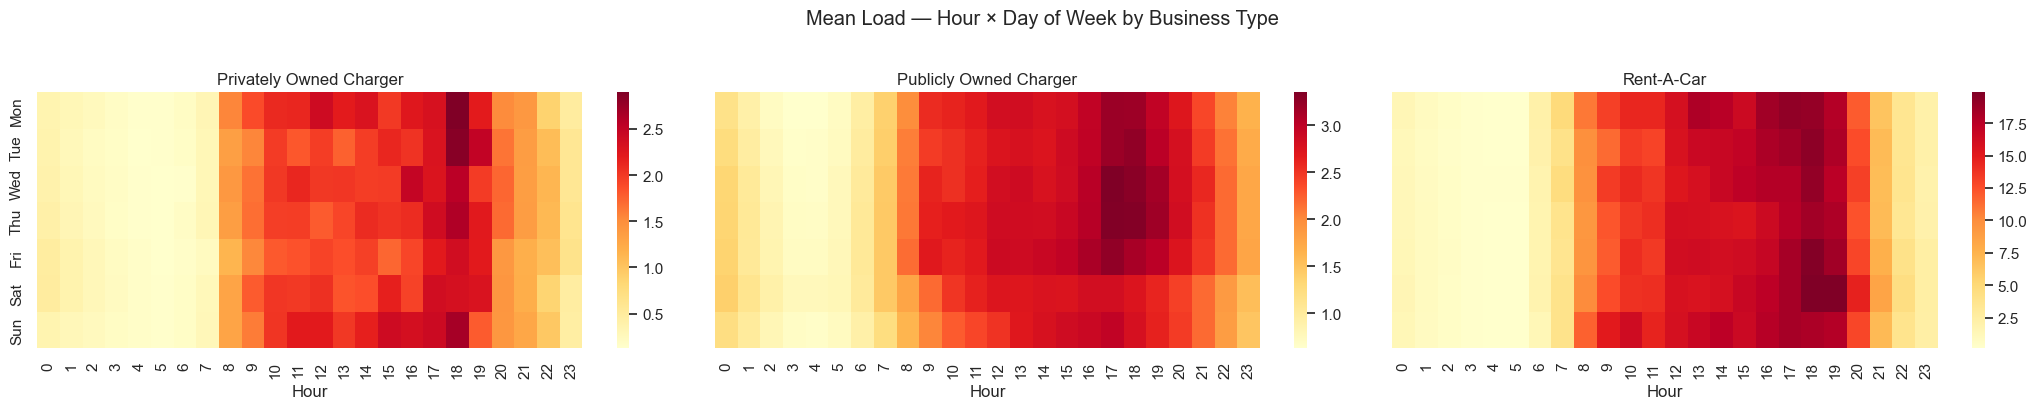

In [ ]:
# --- Heatmap by business type ---
btypes = baseline['business_type'].unique()
fig, axes = plt.subplots(1, len(btypes), figsize=(7 * len(btypes), 4), sharey=True)

if len(btypes) == 1:
    axes = [axes]

for ax, btype in zip(axes, sorted(btypes)):
    sub = baseline[baseline['business_type'] == btype]
    piv = sub.groupby(['day_of_week', 'hour'])['load_kwh_clean'].mean().unstack(fill_value=0)
    sns.heatmap(piv, cmap='YlOrRd', ax=ax, xticklabels=True, yticklabels=dow_labels)
    ax.set_title(btype)
    ax.set_xlabel('Hour')
    ax.set_ylabel('')

plt.suptitle('Mean Load — Hour × Day of Week by Business Type', y=1.02)
plt.tight_layout()
plt.show()

## 5. Demand Response Analysis

How do DR events affect load? When do they occur?

In [ ]:
# --- DR event overview ---
dr_rows = df[df['is_dr_event'] & df['load_kwh_clean'].notna()].copy()
non_dr_rows = baseline.copy()

print(f'DR hours with load data: {len(dr_rows):,}')
print(f'Stations with DR events: {dr_rows["customer_id"].nunique()}')
print(f'\nDR load stats:')
print(dr_rows['load_kwh_clean'].describe())
print(f'\nNon-DR baseline load stats:')
print(non_dr_rows['load_kwh_clean'].describe())

DR hours with load data: 25,175
Stations with DR events: 537

DR load stats:
count   25175.0000
mean        5.3811
std        10.7813
min         0.0000
25%         0.0400
50%         0.1900
75%         6.7300
max       134.1200
Name: load_kwh_clean, dtype: float64

Non-DR baseline load stats:
count   6429940.0000
mean          2.1079
std           8.4982
min           0.0000
25%           0.0230
50%           0.0800
75%           0.2900
max         235.9100
Name: load_kwh_clean, dtype: float64


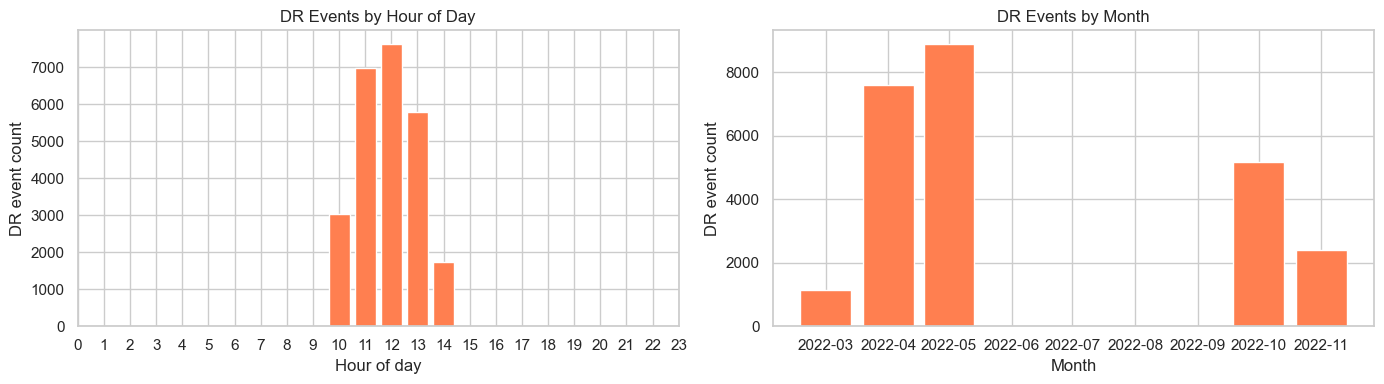

In [ ]:
# --- When do DR events happen? ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dr_hour_dist = dr_rows['hour'].value_counts().sort_index()
axes[0].bar(dr_hour_dist.index, dr_hour_dist.values, color='coral', edgecolor='white')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('DR event count')
axes[0].set_title('DR Events by Hour of Day')
axes[0].set_xticks(range(0, 24))

dr_month_dist = dr_rows.groupby(['year', 'month']).size().reset_index(name='count')
dr_month_dist['date'] = pd.to_datetime(dr_month_dist[['year', 'month']].assign(day=1))
axes[1].bar(dr_month_dist['date'], dr_month_dist['count'], width=25, color='coral', edgecolor='white')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('DR event count')
axes[1].set_title('DR Events by Month')

plt.tight_layout()
plt.show()

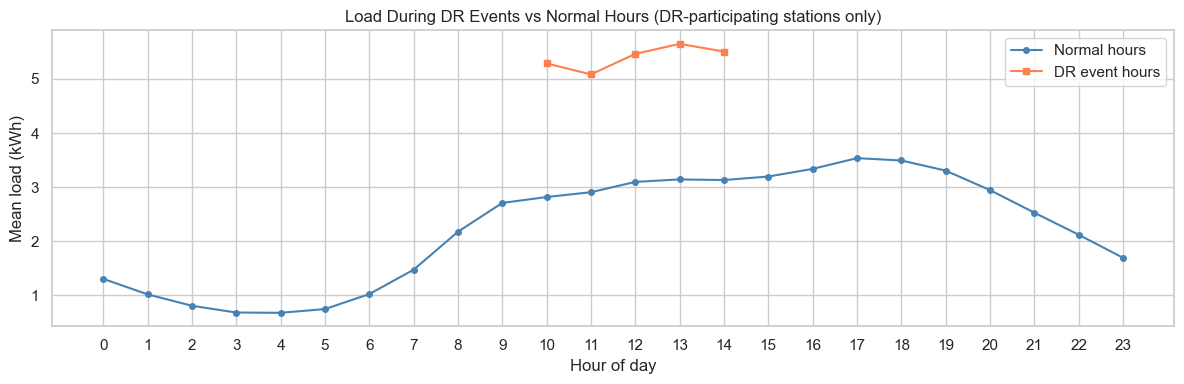

In [ ]:
# --- Load during DR vs same hour non-DR ---
# For stations with DR events, compare their DR-hour load to their typical load at the same hour
dr_stations = dr_rows['customer_id'].unique()

dr_hourly = dr_rows.groupby('hour')['load_kwh_clean'].mean()
non_dr_hourly = baseline[baseline['customer_id'].isin(dr_stations)].groupby('hour')['load_kwh_clean'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(non_dr_hourly.index, non_dr_hourly.values, marker='o', markersize=4, label='Normal hours', color='steelblue')
ax.plot(dr_hourly.index, dr_hourly.values, marker='s', markersize=4, label='DR event hours', color='coral')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean load (kWh)')
ax.set_title('Load During DR Events vs Normal Hours (DR-participating stations only)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature Correlations

Which features are most associated with load?

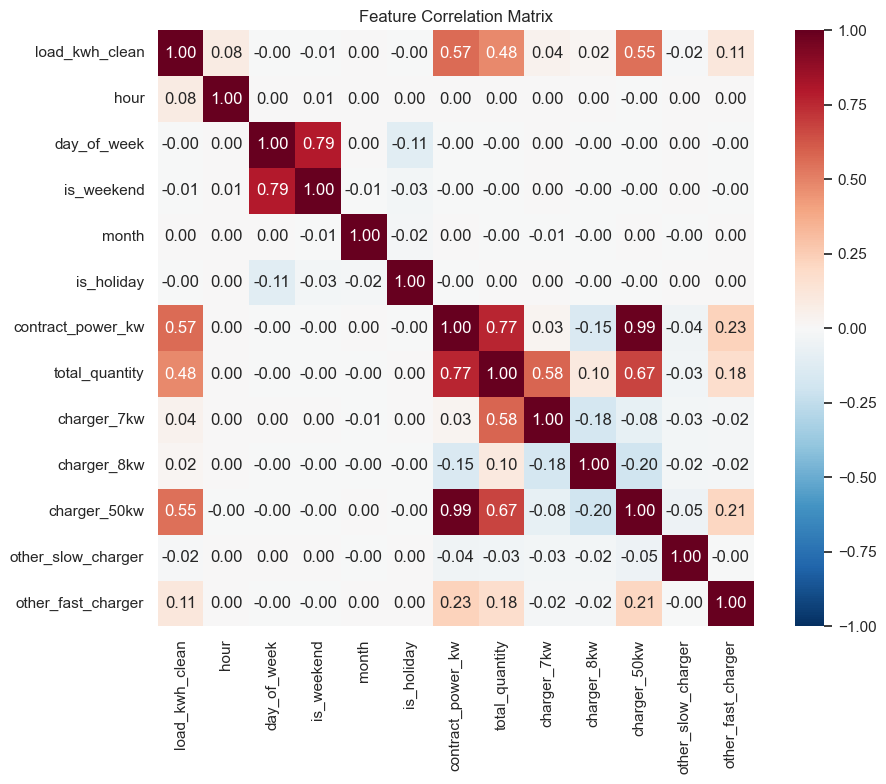

Correlations with load_kwh_clean:
  contract_power_kw         +0.568
  charger_50kw              +0.552
  total_quantity            +0.483
  other_fast_charger        +0.112
  hour                      +0.081
  charger_7kw               +0.039
  charger_8kw               +0.021
  month                     +0.003
  is_holiday                -0.002
  day_of_week               -0.004
  is_weekend                -0.008
  other_slow_charger        -0.015


In [ ]:
# --- Correlation of numeric features with load ---
numeric_features = [
    'load_kwh_clean', 'hour', 'day_of_week', 'is_weekend', 'month',
    'is_holiday', 'contract_power_kw', 'total_quantity',
    'charger_7kw', 'charger_8kw', 'charger_50kw',
    'other_slow_charger', 'other_fast_charger',
]

corr_matrix = baseline[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Sorted correlations with load
load_corr = corr_matrix['load_kwh_clean'].drop('load_kwh_clean').sort_values(ascending=False)
print('Correlations with load_kwh_clean:')
for feat, val in load_corr.items():
    print(f'  {feat:<25} {val:+.3f}')

## 7. Year-over-Year Comparison

Is EV charging growing? Are patterns shifting?

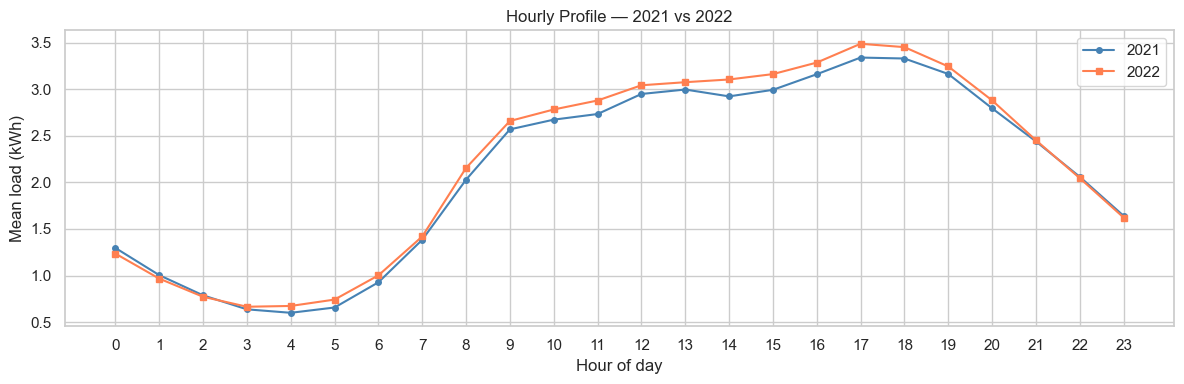

In [ ]:
# --- Hourly profile 2021 vs 2022 ---
h2021 = baseline[baseline['year'] == 2021].groupby('hour')['load_kwh_clean'].mean()
h2022 = baseline[baseline['year'] == 2022].groupby('hour')['load_kwh_clean'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(h2021.index, h2021.values, marker='o', markersize=4, label='2021', color='steelblue')
ax.plot(h2022.index, h2022.values, marker='s', markersize=4, label='2022', color='coral')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean load (kWh)')
ax.set_title('Hourly Profile — 2021 vs 2022')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Data Quality Overview

How much of the data is usable? How are the quality flags distributed?

In [ ]:
# --- Data availability summary ---
total = len(df)
non_null = df['load_kwh_clean'].notna().sum()
null_rows = df['load_kwh_clean'].isna().sum()
outlier_rows = df['load_flag_outlier'].sum()
imputed_rows = df['imputed_ffill'].sum()
dr_rows_total = df['is_dr_event'].sum()
partial_rows = df['partial_hour'].sum()

print(f'Total rows:          {total:>12,}')
print(f'Non-null load:       {non_null:>12,}  ({non_null/total*100:.1f}%)')
print(f'Null load (NaN):     {null_rows:>12,}  ({null_rows/total*100:.1f}%)')
print(f'Outliers flagged:    {outlier_rows:>12,}  ({outlier_rows/total*100:.1f}%)')
print(f'Imputed (ffill):     {imputed_rows:>12,}  ({imputed_rows/total*100:.2f}%)')
print(f'DR event hours:      {dr_rows_total:>12,}  ({dr_rows_total/total*100:.2f}%)')
print(f'Partial hours:       {partial_rows:>12,}  ({partial_rows/total*100:.1f}%)')
print(f'\nBaseline (clean, non-DR, non-outlier, non-imputed): {len(baseline):,}  ({len(baseline)/total*100:.1f}%)')

Total rows:            10,266,720
Non-null load:          7,364,743  (71.7%)
Null load (NaN):        2,901,977  (28.3%)
Outliers flagged:         909,294  (8.9%)
Imputed (ffill):            5,523  (0.05%)
DR event hours:            25,284  (0.25%)
Partial hours:            135,469  (1.3%)

Baseline (clean, non-DR, non-outlier, non-imputed): 6,429,940  (62.6%)


## 9. Key Takeaways

Summary of findings to guide feature engineering and modeling:

*(Fill in after running the notebook)*

1. **Target variable:** ...
2. **Strongest temporal signals:** ...
3. **Station grouping:** ...
4. **Feature candidates:** ...
5. **Modeling considerations:** ...